## Load necessary library files

In [162]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch import from_numpy as tnsr
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

## Used autoregressive model with order K

$\hat{X}(t) = A_1 X(t-1) + A_2 X(t-2) + \cdots + A_k X(t-k)$

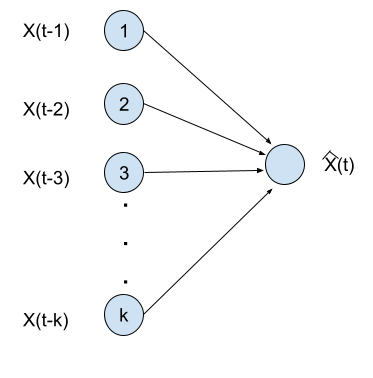

# Used RNN model with order K
$\hat{X}(t) = A_1 X(t-1) + A_2 \hat{X}(t-2) + \cdots + A_k \hat{X}(t-k)$

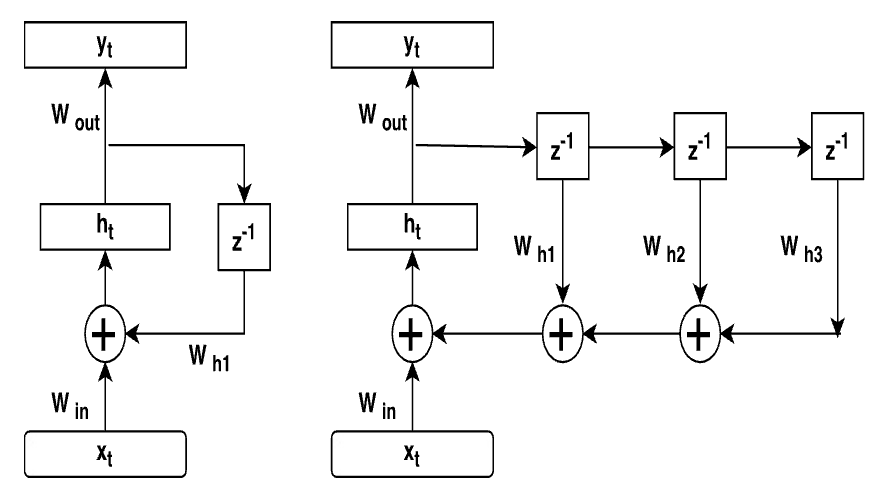

### Figure: Comparison of model structures between an RNN (1st order) and a higher order RNN (3rd order). The symbol $z^{−1}$ denotes a time-delay unit (equivalent to a memory unit). Figure borrowed from [Higher Order Recurrent Neural Networks](https://arxiv.org/pdf/1605.00064)

## Define the naive 1 layer auto-regresssive network

In [163]:
tokens = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

class AR(torch.nn.Module):
    def __init__(self, window):
        super(AR, self).__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(window*len(tokens), len(tokens))
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.layer1(x)

        x = torch.nn.functional.softmax(x, dim=1)

        return x

## Define the RNN model

In [164]:
class RNN(nn.Module):
    # implement RNN from scratch rather than using nn.RNN
    def __init__(self, order):
        super(RNN, self).__init__()
        self.layer1 = nn.Linear(order*len(tokens), len(tokens))
        
    def forward(self, input_tensor, hidden_tensor):
        combined = torch.cat((input_tensor, hidden_tensor), 1)
        
        hidden = self.layer1(combined)
        output = torch.nn.functional.softmax(hidden, dim=1)
        return output
    
    def init_hidden(self):
        return torch.zeros(1, (order-1)*len(tokens))

## Define dataset with one hot encoding

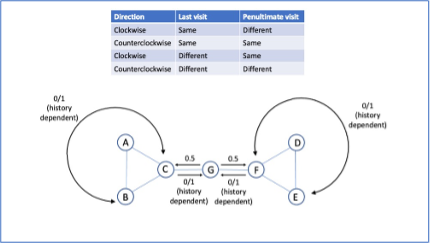

In [165]:
class Dataset_converter(Dataset):
    def __init__(self, data, window=2):
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((len(data)-window, window, len(tokens)))
        self.y = np.zeros((len(data)-window, len(tokens)))

        for ii in range(len(data)-window):
            self.X[ii] = one_hot_encoded[ii:ii+window,:]
            self.y[ii] = one_hot_encoded[ii+window,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [166]:
class Dataset_converter_rnn(Dataset):
    def __init__(self, data):
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((len(data)-1, len(tokens)))
        self.y = np.zeros((len(data)-1, len(tokens)))

        for ii in range(len(data)-1):
            self.X[ii] = one_hot_encoded[ii]
            self.y[ii] = one_hot_encoded[ii+1]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

## Load dataset

In [167]:
data = pd.read_csv("Seq_500000.txt")['seq'][0]

## Perform the experiment for linear AR models(each repeated 10 times)

In [168]:
reps = 10
window_sizes = [8]
lr = 1e-1

test_acc = np.zeros((len(window_sizes), reps, len(data)), dtype=float)
index_len = []

for ii, window in enumerate(window_sizes):
    print('Doing window ', window)
    
    data_set = Dataset_converter(data, window)
    index_len.append(len(data_set))
    
    for rep in tqdm(range(reps)):
        torch.manual_seed(rep)
        model = AR(window)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
        
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        criterion = torch.nn.MSELoss()

        total = 0
        correct = 0
        jj = 0
        for X, y in train_loader:
            optimizer.zero_grad()
            predicted_y = model(X)
            loss = criterion(predicted_y, y)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                total += 1

                if y.argmax() == predicted_y.argmax():
                        correct += 1

                test_acc[ii,rep,jj] = correct/total
                
                #print(f'Iter : {jj+1}, loss: {loss:.4f}')
                jj += 1
            

Doing window  8


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:40<00:00, 46.01s/it]


## Perform the experiment for k-order RNN (each repeated 10 times)

In [179]:
reps = 10
orders = [2, 8, 12, 20]
lr = 1e-1

test_acc_rnn = np.zeros((len(orders), reps, len(data)-1), dtype=float)
index_len = []

for ii, order in enumerate(orders):
    print('Doing order ', order)
    
    data_set = Dataset_converter_rnn(data)
    
    for rep in tqdm(range(reps)):
        torch.manual_seed(rep)
        model = RNN(order)
        hidden_memory = model.init_hidden()
        
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
        
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        criterion = torch.nn.MSELoss()

        total = 0
        correct = 0
        jj = 0
        for X, y in train_loader:
            optimizer.zero_grad()
            predicted_y = model(X, hidden_memory)
            
            with torch.no_grad():
                hidden_memory[0,len(tokens):] = hidden_memory[0,:-len(tokens)].clone()
                hidden_memory[0,:len(tokens)] = predicted_y
            
            loss = criterion(predicted_y, y)
            loss.backward()

            #torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()

            with torch.no_grad():
                total += 1

                if y.argmax() == predicted_y.argmax():
                        correct += 1

                test_acc_rnn[ii,rep,jj] = correct/total

                # if jj%10000 == 0:
                #     print(f'Iter : {jj+1}, loss: {loss:.4f}')
                jj += 1
            

Doing order  2


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [08:33<00:00, 51.40s/it]


Doing order  8


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [08:31<00:00, 51.17s/it]


Doing order  12


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [08:30<00:00, 51.05s/it]


Doing order  20


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [08:30<00:00, 51.08s/it]


## Plot the result

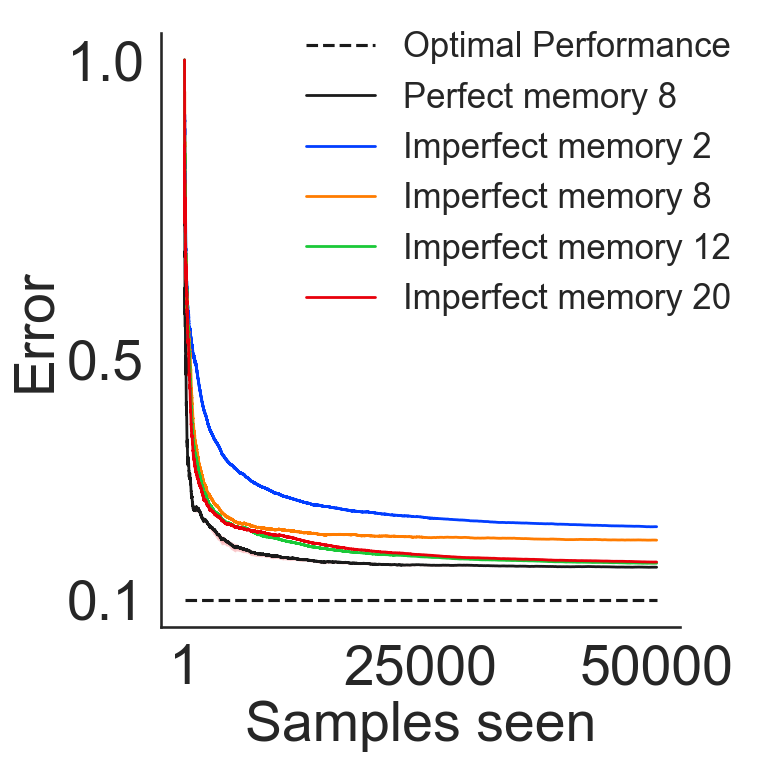

In [181]:
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40
samples_to_show = 50000

fig, ax = plt.subplots(1, 1, figsize=(8,8))

ax.hlines(0.1, 0, samples_to_show, linestyles='dashed', label='Optimal Performance', color='k')
# for ii, win in enumerate(window_sizes):
#     ax.plot(np.arange(1,samples_to_show+1), np.median(test_acc[ii,:,:samples_to_show],axis=0),linewidth=2, label='window '+ str(win))
#     ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(test_acc[ii,:,:samples_to_show], 0.25, axis=0), np.quantile(test_acc[ii,:,:samples_to_show], 0.75, axis=0), alpha=.3)

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc[0,:,:samples_to_show],axis=0),linewidth=2, c='k', label='Perfect memory 8')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc[0,:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc[0,:,:samples_to_show], 0.75, axis=0), facecolor='r', alpha=.3)


# ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc_rnn[0,:,:samples_to_show],axis=0),linewidth=2, c='b', label='Imperfect memory')
# ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc_rnn[0,:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc_rnn[0,:,:samples_to_show], 0.75, axis=0), facecolor='b', alpha=.3)

for ii, ordr in enumerate(orders):
    ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc_rnn[ii,:,:samples_to_show],axis=0),linewidth=2, label='Imperfect memory '+ str(ordr))
    ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc_rnn[ii,:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc_rnn[ii,:,:samples_to_show], 0.75, axis=0), alpha=.3)

leg = fig.legend(fontsize=25, frameon=False)


ax.set_xticks([1, samples_to_show//2, samples_to_show])
ax.set_yticks([0.1, 0.5, 1.0])

ax.set_xlabel('Samples seen', fontsize=font)
ax.set_ylabel('Error', fontsize=font)

ax.tick_params(labelsize=40)
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

plt.tight_layout()


## Todos
1. converegence speed, 
2. Train RNN better, 